# group > halo mapping

In [1]:
import sys
sys.path.insert(0,'./g3algo/')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from center_binned_stats import center_binned_stats as cbs
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
import matplotlib.patches as mpatches
from scipy.stats import ks_2samp
from foftools import multiplicity_function

rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
cspeed=2.998e+5

g3pur=[]
g3comp=[]
g3logmh=[]
for ii in range(0,8):
    g3=pd.read_csv('./halobiasgroupcats/fiducial/ECO_cat_{}_Planck_memb_cat.csv'.format(ii))
    my_halo_ngal = multiplicity_function(g3.haloid.to_numpy(),True)
    g3=g3[(g3.halo_ngal.to_numpy()==my_halo_ngal)]
    #g3=g3[(g3.g3grpngi_l+g3.g3grpndw_l)>1]
    g3=g3[(g3.g3logmh_l>0)].groupby('g3grp_l').first() # get each group
    g3pur.append(np.array(g3.group_purity))
    g3comp.append(np.array(g3.group_comp))
    g3logmh.append(np.array(g3.g3logmh_l))
g3pur=np.concatenate(g3pur)
g3comp=np.concatenate(g3comp)
g3logmh=np.concatenate(g3logmh)

In [2]:
fofpur=[]
fofcomp=[]
foflogmh=[]
for ii in range(0,8):
    fof=pd.read_csv('./halobiasgroupcats/fiducial/ECO_cat_{}_Planck_memb_cat.csv'.format(ii))
    my_halo_ngal = multiplicity_function(fof.haloid.to_numpy(),True)
    fof = fof[(fof.halo_ngal.to_numpy()==my_halo_ngal)]
    fof.loc[:,'fofe17grpn']=multiplicity_function(np.array(fof.fofe17id),return_by_galaxy=True)
    #fof=fof[fof.fofe17grpn>1]
    fof=fof[(fof.fofe17logmh>0)].groupby('fofe17id').first() # get each group
    fofpur.append(np.array(fof.fofe17purity_g))
    fofcomp.append(fof.fofe17completeness_g)
    foflogmh.append(np.array(fof.fofe17logmh))
fofpur=np.concatenate(fofpur)
fofcomp=np.concatenate(fofcomp)
foflogmh=np.concatenate(foflogmh)

In [3]:
len(fofpur),len(g3pur)

(64062, 69041)

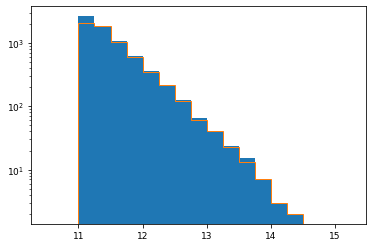

In [4]:
plt.figure()
bins=np.arange(10.5,15.5,0.25)
plt.hist(g3.g3logmh_l,bins=bins)
plt.hist(fof.fofe17logmh,bins=bins, histtype='step')
plt.yscale('log')
plt.show()

In [5]:
len(g3),len(fof)

(7058, 6419)

In [6]:
print(np.mean(g3comp),np.mean(g3pur))
print(np.median(g3comp),np.median(g3pur))

0.8907295828670184 0.9910713500156451
1.0 1.0


In [7]:
print(np.mean(fofcomp), np.mean(fofpur))
print(np.median(fofcomp), np.median(fofpur))

0.9212594104290595 0.9721736156973683
1.0 1.0


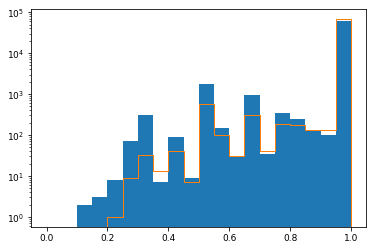

1.0 1.0


KstestResult(statistic=0.041826322780266774, pvalue=3.081789864745006e-51)

In [8]:
plt.figure()
bins=np.arange(0,1.05,0.05)
plt.hist(fofpur,bins=bins,log=True)
plt.hist(g3pur,bins=bins, log=True, histtype='step')
plt.show()
print(np.median(fofpur),np.median(g3pur))
ks_2samp(fofpur,g3pur,'greater')

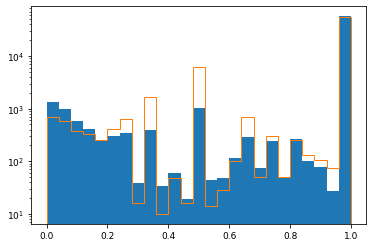

KstestResult(statistic=0.022912790913225185, pvalue=6.878180848814556e-16)

In [9]:
plt.figure()
bins=np.arange(0,1.04,0.04)
plt.hist(fofcomp,bins=bins,log=True)
plt.hist(g3comp,bins=bins, log=True, histtype='step')
plt.show()
ks_2samp(fofcomp,g3comp,'greater')

# purity, compl

KstestResult(statistic=0.041826322780266774, pvalue=3.081789864745006e-51)
KstestResult(statistic=0.022912790913225185, pvalue=6.878180848814556e-16)


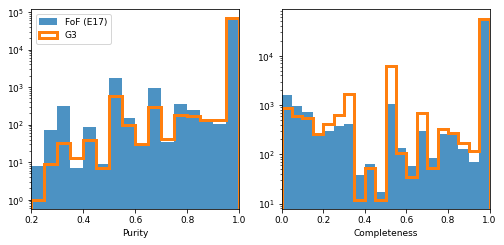

In [10]:
fig,axs=plt.subplots(ncols=2,figsize=(doublecolsize[0],0.8*doublecolsize[1]))
bins=np.arange(0,1.05,0.05)
axs[0].hist(fofpur,bins=bins,log=True,label='FoF (E17)',alpha=0.8)
axs[0].hist(g3pur,bins=bins,log=True, histtype='step', label='G3', linewidth=3)
print(ks_2samp(fofpur,g3pur,'greater'))
axs[0].set_xlim(0.2,1)
axs[0].set_xlabel("Purity")
axs[0].legend(loc='upper left')

axs[1].hist(fofcomp,bins=bins,log=True, alpha=0.8)
axs[1].hist(g3comp,bins=bins, log=True, histtype='step',linewidth=3)
print(ks_2samp(fofcomp,g3comp,'greater'))
axs[1].set_xlim(0,1)
axs[1].set_xlabel("Completeness")
plt.tight_layout()
plt.show()

## purity, completeness vs. mass

Purity (G3):  [1.  1.  1.  0.9]
Purity (FoF):  [1.         1.         1.         0.93218391]
Completeness (G3):  [1.  1.  1.  0.9]
Completeness (FoF):  [1.         1.         0.9        0.77777778]
hmm 69041 64062
hmm 69041 64062


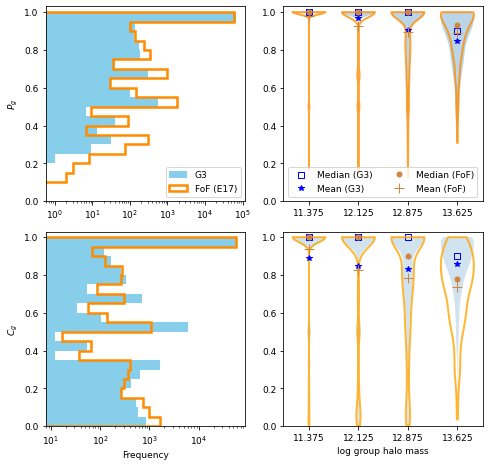

KstestResult(statistic=0.041826322780266774, pvalue=3.081789864745006e-51)
KstestResult(statistic=0.022912790913225185, pvalue=6.878180848814556e-16)
0.9910713500156451 0.9721736156973683
0.8907295828670184 0.9212594104290595


In [11]:
fig,axs=plt.subplots(ncols=2,nrows=2,figsize=(doublecolsize[0],doublecolsize[1]*1.5))

# axs[0] - purity for g3 grps
binv = np.arange(11,14.5,0.75)
vdata = [np.array(g3pur[np.where(np.logical_and(g3logmh>binv[ii],g3logmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Purity (G3): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[0][1].violinplot(vdata,binc,showextrema=False)
axs[0][1].scatter(binc,medians,marker='s',facecolor='none',edgecolor='blue', label='Median (G3)')
axs[0][1].plot(binc,means,'b*', label='Mean (G3)')
axs[0][1].set_ylim(0.6,1.05)

# axs[0] - purity for fof grps
vdata = [np.array(fofpur[np.where(np.logical_and(foflogmh>binv[ii],foflogmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Purity (FoF): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[0][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("None")
    pc.set_edgecolor('darkorange')
    pc.set_linewidth(2)
    pc.set_alpha(0.8)
axs[0][1].plot(binc,medians,'.',color='peru', label='Median (FoF)',markersize=10)
axs[0][1].plot(binc,means,'+',color='peru', label='Mean (FoF)',markersize=10)
axs[0][1].legend(loc='best',ncol=2)
axs[0][1].set_xticks(binc, label=['{:0.2f}'.format(bv) for bv in binv])


# axs[1] - compl for g3 grps
vdata = [np.array(g3comp[np.where(np.logical_and(g3logmh>binv[ii],g3logmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Completeness (G3): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[1][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.2)
axs[1][1].scatter(binc,medians,marker='s', facecolor='none', edgecolor='blue')
axs[1][1].plot(binc,means,'b*')
#axs[1].set_ylim(0.6,1.05)

# axs[1] - compl for fof grps
vdata = [np.array(fofcomp[np.where(np.logical_and(foflogmh>binv[ii],foflogmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Completeness (FoF): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[1][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("None")
    pc.set_edgecolor('orange')
    pc.set_linewidth(2)
    pc.set_alpha(0.8)
axs[1][1].plot(binc,medians,'.', color='peru',markersize=10)
axs[1][1].plot(binc,means,'+', color='peru',markersize=10)
axs[1][1].set_xticks(binc, label=['{:0.2f}'.format(bv) for bv in binv])


binv=np.arange(0,1.05,0.05)
axs[0][0].hist(g3pur,bins=binv,log=True,orientation='horizontal',label='G3',color='skyblue')
axs[0][0].hist(fofpur,bins=binv,log=True,orientation='horizontal',color='darkorange',histtype='step',linewidth=2.5, label='FoF (E17)')
print('hmm',len(g3pur),len(fofpur))
axs[1][0].hist(g3comp,bins=binv,log=True,orientation='horizontal',color='skyblue')
axs[1][0].hist(fofcomp,bins=binv,log=True,orientation='horizontal',histtype='step',linewidth=2.5,color='darkorange')
print('hmm',len(g3comp),len(fofcomp))
axs[0][0].legend(loc='lower right')

axs[0][0].set_ylabel(r"$P_g$")
axs[1][0].set_ylabel(r"$C_g$")
axs[1][1].set_xlabel("log group halo mass")
axs[1][0].set_xlabel("Frequency")

for ii in range(0,2):
    for jj in range(0,2):
        axs[ii][jj].set_ylim(0,1.03)
plt.tight_layout()
plt.savefig("./figures/pur_comp_dists.pdf",dpi=300)
plt.show()

print(ks_2samp(g3pur,fofpur,'less'))
print(ks_2samp(g3comp,fofcomp,'less'))
print(np.mean(g3pur),np.mean(fofpur))
print(np.mean(g3comp),np.mean(fofcomp))

In [12]:
len(fofpur),len(g3pur)

(64062, 69041)

# now halo>group mapping

In [13]:
%reset -f

In [24]:
import sys
sys.path.insert(0,'./g3algo/')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from center_binned_stats import center_binned_stats as cbs
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
import matplotlib.patches as mpatches
from scipy.stats import ks_2samp
from foftools import multiplicity_function

rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
cspeed=2.998e+5

g3pur=[]
g3comp=[]
g3logmh=[]
for ii in range(0,8):
    g3=pd.read_csv('./halobiasgroupcats/fiducial/ECO_cat_{}_Planck_memb_cat.csv'.format(ii))
    my_halo_ngal = multiplicity_function(g3.haloid.to_numpy(),True)
    g3=g3[(g3.halo_ngal.to_numpy()==my_halo_ngal)]
    g3=g3.groupby('haloid').first()
    g3pur.append(np.array(g3.halo_purity))
    g3comp.append(np.array(g3.halo_comp))
    g3logmh.append(np.array(g3.loghalom))
g3pur=np.concatenate(g3pur)
g3comp=np.concatenate(g3comp)
g3logmh=np.concatenate(g3logmh)

In [25]:
fofpur=[]
fofcomp=[]
foflogmh=[]
for ii in range(0,8):
    fof=pd.read_csv('./halobiasgroupcats/fiducial/ECO_cat_{}_Planck_memb_cat.csv'.format(ii))
    my_halo_ngal = multiplicity_function(fof.haloid.to_numpy(),True)
    fof = fof[(fof.halo_ngal.to_numpy()==my_halo_ngal)]
    fof.loc[:,'fofe17grpn']=multiplicity_function(np.array(fof.fofe17id),return_by_galaxy=True)
    #fof=fof[fof.fofe17grpn>1]
    #fof=fof[(fof.fofe17logmh>0)].groupby('fofe17id').first() # get each group
    fof = fof.groupby('haloid').first()
    fofpur.append(np.array(fof.fofe17purity_h))
    fofcomp.append(fof.fofe17completeness_h)
    foflogmh.append(np.array(fof.loghalom))
fofpur=np.concatenate(fofpur)
fofcomp=np.concatenate(fofcomp)
foflogmh=np.concatenate(foflogmh)

Purity (G3):  [1.         1.         1.         0.91304348]
Purity (FoF):  [1. 1. 1. 1.]
Completeness (G3):  [1.         1.         0.875      0.83333333]
Completeness (FoF):  [1.         1.         0.83333333 0.64179104]
hmm 64289 64289
hmm 64289 64289


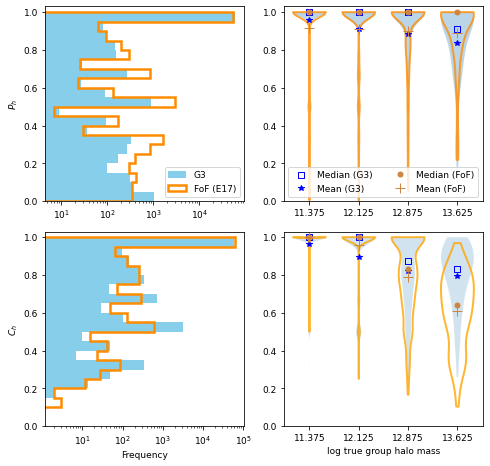

KstestResult(statistic=0.07293627214609032, pvalue=2.7567776814723388e-149)
KstestResult(statistic=4.6664281603384714e-05, pvalue=0.9998133602929441)
0.9528275795100044 0.915695837765102
0.9629617589387731 0.9882103325435853


In [26]:
fig,axs=plt.subplots(ncols=2,nrows=2,figsize=(doublecolsize[0],doublecolsize[1]*1.5))

# axs[0] - purity for g3 grps
binv = np.arange(11,14.5,0.75)
vdata = [np.array(g3pur[np.where(np.logical_and(g3logmh>binv[ii],g3logmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Purity (G3): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[0][1].violinplot(vdata,binc,showextrema=False)
axs[0][1].scatter(binc,medians,marker='s',facecolor='none',edgecolor='blue', label='Median (G3)')
axs[0][1].plot(binc,means,'b*', label='Mean (G3)')
axs[0][1].set_ylim(0.6,1.05)

# axs[0] - purity for fof grps
vdata = [np.array(fofpur[np.where(np.logical_and(foflogmh>binv[ii],foflogmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Purity (FoF): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[0][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("None")
    pc.set_edgecolor('darkorange')
    pc.set_linewidth(2)
    pc.set_alpha(0.8)
axs[0][1].plot(binc,medians,'.',color='peru', label='Median (FoF)',markersize=10)
axs[0][1].plot(binc,means,'+',color='peru', label='Mean (FoF)',markersize=10)
axs[0][1].legend(loc='best',ncol=2)
axs[0][1].set_xticks(binc, label=['{:0.2f}'.format(bv) for bv in binv])


# axs[1] - compl for g3 grps
vdata = [np.array(g3comp[np.where(np.logical_and(g3logmh>binv[ii],g3logmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Completeness (G3): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[1][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.2)
axs[1][1].scatter(binc,medians,marker='s', facecolor='none', edgecolor='blue')
axs[1][1].plot(binc,means,'b*')
#axs[1].set_ylim(0.6,1.05)

# axs[1] - compl for fof grps
vdata = [np.array(fofcomp[np.where(np.logical_and(foflogmh>binv[ii],foflogmh<=binv[ii+1]))]) for ii in range(0,len(binv)-1)]
vdata=np.array(vdata,dtype=object)
vstats = np.array([np.percentile(col,[16,50,84]) for col in vdata])
means = np.array([np.mean(col) for col in vdata])
medians = np.array([np.median(col) for col in vdata])
print("Completeness (FoF): ",medians)
binc = 0.5*(binv[:-1]+binv[1:])
parts=axs[1][1].violinplot(vdata,binc,showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("None")
    pc.set_edgecolor('orange')
    pc.set_linewidth(2)
    pc.set_alpha(0.8)
axs[1][1].plot(binc,medians,'.', color='peru',markersize=10)
axs[1][1].plot(binc,means,'+', color='peru',markersize=10)
axs[1][1].set_xticks(binc, label=['{:0.2f}'.format(bv) for bv in binv])


binv=np.arange(0,1.05,0.05)
axs[0][0].hist(g3pur,bins=binv,log=True,orientation='horizontal',label='G3',color='skyblue')
axs[0][0].hist(fofpur,bins=binv,log=True,orientation='horizontal',color='darkorange',histtype='step',linewidth=2.5, label='FoF (E17)')
print('hmm',len(g3pur),len(fofpur))
axs[1][0].hist(g3comp,bins=binv,log=True,orientation='horizontal',color='skyblue')
axs[1][0].hist(fofcomp,bins=binv,log=True,orientation='horizontal',histtype='step',linewidth=2.5,color='darkorange')
print('hmm',len(g3comp),len(fofcomp))
axs[0][0].legend(loc='lower right')

axs[0][0].set_ylabel(r"$P_h$")
axs[1][0].set_ylabel(r"$C_h$")
axs[1][1].set_xlabel("log true group halo mass")
axs[1][0].set_xlabel("Frequency")

for ii in range(0,2):
    for jj in range(0,2):
        axs[ii][jj].set_ylim(0,1.03)
plt.tight_layout()
plt.savefig("./figures/pur_comp_dists_halo.pdf",dpi=300)
plt.show()

print(ks_2samp(g3pur,fofpur,'less'))
print(ks_2samp(g3comp,fofcomp,'less'))
print(np.mean(g3pur),np.mean(fofpur))
print(np.mean(g3comp),np.mean(fofcomp))

In [29]:
mock = pd.read_csv("halobiasgroupcats/fiducial/ECO_cat_0_Planck_memb_cat.csv")
my_halo_ngal = multiplicity_function(mock.haloid.to_numpy(),True)
mock = mock[(mock.halo_ngal.to_numpy()==my_halo_ngal)]

In [30]:
mock[(mock.halo_comp<0.3)&(mock.loghalom>13)]

,Unnamed: 0,loghalom,cs_flag,haloid,halo_ngal,M_r,dist_c,morph,rmag,umag,...,group_comp,halo_purity,halo_comp,fofe17id,fofe17grpn,fofe17logmh,fofe17purity_g,fofe17completeness_g,fofe17purity_h,fofe17completeness_h
12398,13145,13.077,1,1699304,7,-21.577475,0.000000,b'ET',-21.653639,-19.368118,...,0.285714,1.0,0.285714,7657.0,4,12.444,0.750000,0.428571,0.75,0.428571
12399,13146,13.077,0,1699304,7,-20.601488,0.379135,b'ET',-20.645945,-18.330238,...,0.285714,1.0,0.285714,7657.0,4,12.444,0.750000,0.428571,0.75,0.428571
12400,13147,13.077,0,1699304,7,-19.634176,0.384961,b'LT',-19.615767,-18.320641,...,0.142857,1.0,0.285714,7658.0,2,11.592,1.000000,0.285714,0.75,0.428571
12401,13148,13.077,0,1699304,7,-18.870117,0.460715,b'LT',-18.916628,-16.806095,...,0.142857,1.0,0.285714,7657.0,4,12.444,0.750000,0.428571,0.75,0.428571
12402,13149,13.077,0,1699304,7,-21.368032,0.450710,b'LT',-21.407978,-19.197392,...,0.285714,1.0,0.285714,7659.0,3,12.161,0.333333,0.142857,0.75,0.428571
12403,13150,13.077,0,1699304,7,-18.711884,0.407595,b'ET',-18.741091,-16.781528,...,0.142857,1.0,0.285714,7658.0,2,11.592,1.000000,0.285714,0.75,0.428571
12404,13151,13.077,0,1699304,7,-19.592552,0.457716,b'LT',-19.585793,-18.104267,...,0.285714,1.0,0.285714,7660.0,1,11.472,1.000000,0.142857,0.75,0.428571


In [32]:
mock[mock.haloid==235801][['haloid','g3grp_l','group_purity','group_comp','halo_purity','halo_comp','halo_ngal']]

,haloid,g3grp_l,group_purity,group_comp,halo_purity,halo_comp,halo_ngal
1512,235801,245.0,1.000000,0.285714,0.105263,0.285714,7
1513,235801,243.0,0.736842,0.875000,0.105263,0.285714,7
1514,235801,245.0,1.000000,0.285714,0.105263,0.285714,7
1515,235801,246.0,1.000000,0.142857,0.105263,0.285714,7
1516,235801,244.0,0.800000,1.000000,0.105263,0.285714,7
1517,235801,244.0,0.800000,1.000000,0.105263,0.285714,7
1518,235801,243.0,0.736842,0.875000,0.105263,0.285714,7


In [35]:
mock[mock.g3grp_l==243.]

,Unnamed: 0,loghalom,cs_flag,haloid,halo_ngal,M_r,dist_c,morph,rmag,umag,...,group_comp,halo_purity,halo_comp,fofe17id,fofe17grpn,fofe17logmh,fofe17purity_g,fofe17completeness_g,fofe17purity_h,fofe17completeness_h
1479,1565,12.816,1,235712,6,-21.977795,0.000000,b'LT',-22.031893,-19.767315,...,0.875,0.157895,0.500000,962.0,6,12.712,0.833333,0.833333,0.833333,0.833333
1480,1566,12.816,0,235712,6,-20.885612,0.196019,b'ET',-20.925991,-18.586823,...,0.875,0.157895,0.500000,962.0,6,12.712,0.833333,0.833333,0.833333,0.833333
1484,1570,12.816,0,235712,6,-20.137316,0.264174,b'LT',-20.150642,-18.314369,...,0.875,0.157895,0.500000,963.0,1,11.625,1.000000,0.166667,0.833333,0.833333
1495,1581,13.373,1,235794,16,-22.280247,0.000000,b'ET',-22.344347,-20.004780,...,0.875,0.736842,0.875000,966.0,9,13.349,1.000000,0.562500,1.000000,0.562500
1496,1582,13.373,0,235794,16,-22.179718,0.381451,b'ET',-22.236053,-19.834412,...,0.875,0.736842,0.875000,966.0,9,13.349,1.000000,0.562500,1.000000,0.562500
1497,1583,13.373,0,235794,16,-20.995115,0.175342,b'LT',-21.046844,-18.697769,...,0.875,0.736842,0.875000,967.0,1,11.921,1.000000,0.062500,1.000000,0.562500
1499,1585,13.373,0,235794,16,-19.662323,0.281158,b'LT',-19.638195,-18.333763,...,0.875,0.736842,0.875000,969.0,2,11.732,1.000000,0.125000,1.000000,0.562500
1500,1586,13.373,0,235794,16,-19.783190,0.289092,b'ET',-19.811388,-17.604828,...,0.875,0.736842,0.875000,969.0,2,11.732,1.000000,0.125000,1.000000,0.562500
1501,1587,13.373,0,235794,16,-18.467169,0.146719,b'LT',-18.483706,-17.328220,...,0.875,0.736842,0.875000,966.0,9,13.349,1.000000,0.562500,1.000000,0.562500
1502,1588,13.373,0,235794,16,-18.918777,0.558139,b'LT',-18.907785,-17.665707,...,0.875,0.736842,0.875000,962.0,6,12.712,0.833333,0.833333,1.000000,0.562500


In [20]:
mock.keys()

Index(['Unnamed: 0', 'loghalom', 'cs_flag', 'haloid', 'halo_ngal', 'M_r',
       'dist_c', 'morph', 'rmag', 'umag', 'logmstar', 'fsmgr', 'mhi',
       'survey_flag', 'u_r', 'r_dist', 'ra', 'dec', 'cz', 'cz_nodist',
       'vel_tot', 'vel_tan', 'groupid', 'M_group', 'g_ngal', 'g_galtype',
       'halo_rvir', 'g3grp_l', 'g3grpn_l', 'g3logmh_l', 'mu_HME',
       'group_purity', 'group_comp', 'halo_purity', 'halo_comp', 'fofe17id',
       'fofe17grpn', 'fofe17logmh', 'fofe17purity_g', 'fofe17completeness_g',
       'fofe17purity_h', 'fofe17completeness_h'],
      dtype='object')